# Ascending Φ: gradient ascent on integrated information

Can a system be *pushed* toward higher integrated information by following the
gradient of Φ itself? To our knowledge this has never been done: previous work that
increased Φ used evolutionary search or task selection, and the one study that
optimized Φ directly (a guided random search over TPMs) stated explicitly that
gradients were not available. In `iitx` they are: the IIT 4.0 pipeline is
differentiable almost everywhere with respect to the transition probabilities, with
exact subgradients at the min/max seams (see `docs/notes/phi-optimization.md` for the
literature).

This notebook runs the experiment at `n = 3`, small enough that every step's exact
Φ-structure is verifiable — and large enough to watch structure emerge.

**The objective.** We parameterize a conditionally independent TPM by logits (one per
unit and prior state) and ascend `soft_system_phi` — a smooth surrogate that softens
only the *partition selection* of the exact signed φ_s (temperature → 0 recovers the
exact value). The temperature is *annealed* (0.5 → 0.005): smooth early to escape
low ridges, sharp late so the surrogate converges to the exact objective — the
schedule selected by the gradient audit in `experiments/e00_gradient_audit.ipynb`.
The exact quantities are computed alongside at every step; the surrogate is never
reported as Φ.

In [1]:
import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from iitx.measures import iit4
from iitx.relax import soft_system_phi
from iitx.system import System

N = 3
STATE = jnp.asarray([0] * N)
# Annealed softmin temperature (see experiments/e00_gradient_audit.ipynb: the
# surrogate's bias plateaus at ~0.06 ibits until tau falls below ~0.01, and an
# annealed schedule decisively beats any fixed temperature on matched seeds).
TAU_START, TAU_END = 0.5, 0.005

In [2]:
def build(logits):
	"""A conditionally independent binary system from per-unit ON-logits."""
	return System.from_state_by_node(jax.nn.sigmoid(logits))


def objective(logits, temperature):
	return soft_system_phi(build(logits), STATE, temperature=temperature)


# Adam, in eight lines (kept inline to keep the library lean).
def adam_step(params, grads, m, v, step, lr=0.02, b1=0.9, b2=0.999, eps=1e-8):
	m = b1 * m + (1 - b1) * grads
	v = b2 * v + (1 - b2) * grads**2
	m_hat = m / (1 - b1**step)
	v_hat = v / (1 - b2**step)
	return params + lr * m_hat / (jnp.sqrt(v_hat) + eps), m, v


value_and_grad = jax.jit(jax.value_and_grad(objective))  # gradient w.r.t. logits only
exact = jax.jit(lambda logits: iit4.system_phi(build(logits), STATE))

In [3]:
rng = np.random.default_rng(0)
logits = jnp.asarray(0.5 * rng.standard_normal((2**N, N)))

STEPS = 600
m = jnp.zeros_like(logits)
v = jnp.zeros_like(logits)
history = {"soft": [], "signed": [], "phi_s": [], "cuts": [], "big_phi": [], "distinctions": []}
snapshots = {0: np.asarray(jax.nn.sigmoid(logits))}

for step in range(1, STEPS + 1):
	tau = TAU_START * (TAU_END / TAU_START) ** (step / STEPS)
	soft, grads = value_and_grad(logits, tau)
	logits, m, v = adam_step(logits, grads, m, v, step)

	analysis = exact(logits)
	history["soft"].append(float(soft))
	history["signed"].append(float(analysis.signed_phi))
	history["phi_s"].append(float(analysis.phi))
	cuts = iit4.partition_phis(build(logits), STATE)
	history["cuts"].append(np.asarray(cuts.phi / cuts.severed))
	if step % 25 == 0 or step == 1:
		structure = jax.jit(iit4.phi_structure)(build(logits), STATE)
		history["big_phi"].append((step, float(structure.big_phi)))
		history["distinctions"].append((step, int(np.asarray(structure.distinctions.exists).sum())))

snapshots[STEPS] = np.asarray(jax.nn.sigmoid(logits))
print(f"signed phi_s: {history['signed'][0]:.4f} -> {history['signed'][-1]:.4f}")
print(f"big Phi:      {history['big_phi'][0][1]:.4f} -> {history['big_phi'][-1][1]:.4f}")

signed phi_s: -0.0125 -> 2.3370
big Phi:      0.5416 -> 17.3702


## The ascent

Early, at high temperature, the surrogate averages over many partitions and sits well
below the exact signed φ_s — it is smoothing the landscape, not yet estimating it. As
the temperature anneals the two curves merge, and by the end the surrogate *is* the
exact objective to within the final temperature. φ_s (the clamped, reported quantity)
shows the system escaping reducibility and integrating.

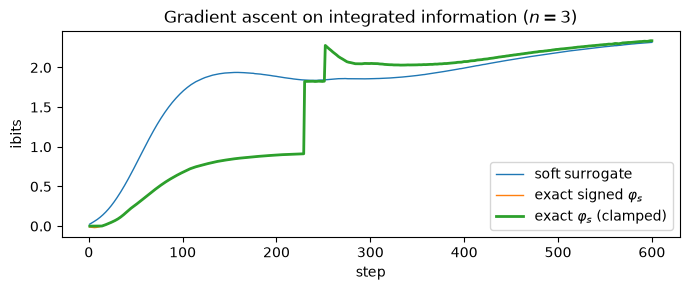

In [4]:
steps = np.arange(1, STEPS + 1)
plt.figure(figsize=(7, 3))
plt.plot(steps, history["soft"], label="soft surrogate", lw=1)
plt.plot(steps, history["signed"], label=r"exact signed $\varphi_s$", lw=1)
plt.plot(steps, history["phi_s"], label=r"exact $\varphi_s$ (clamped)", lw=2)
plt.xlabel("step")
plt.ylabel("ibits")
plt.legend()
plt.title(r"Gradient ascent on integrated information ($n=3$)")
plt.tight_layout()

## No weakest link: the cut spectrum compresses

φ_s is a minimum over every directional partition. Ascent therefore works on the
*weakest* cut; when it catches up with the others, the active minimum switches — the
kinks in the trajectory. The spread of normalized cut values narrows: the system grows
integration without fault lines.

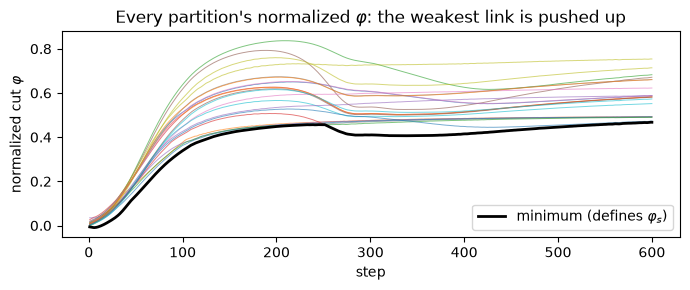

In [5]:
cut_matrix = np.stack(history["cuts"])
plt.figure(figsize=(7, 3))
for k in range(cut_matrix.shape[1]):
	plt.plot(steps, cut_matrix[:, k], lw=0.7, alpha=0.6)
plt.plot(steps, cut_matrix.min(axis=1), color="black", lw=2, label="minimum (defines $\\varphi_s$)")
plt.xlabel("step")
plt.ylabel("normalized cut $\\varphi$")
plt.legend()
plt.title("Every partition's normalized $\\varphi$: the weakest link is pushed up")
plt.tight_layout()

## Structure emerges

φ_s only measures *that* the system holds together. Watching the Φ-structure during an
ascent on φ_s answers a sharper question: does existence bring *content*? Here the
number of congruent distinctions and their total with relations — big Φ — rise with
φ_s, without ever being optimized directly.

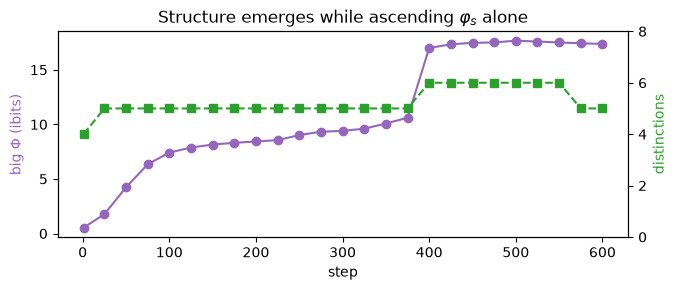

In [6]:
big_steps, big_values = zip(*history["big_phi"], strict=True)
d_steps, d_values = zip(*history["distinctions"], strict=True)

fig, left = plt.subplots(figsize=(7, 3))
left.plot(big_steps, big_values, "o-", color="tab:purple", label=r"big $\Phi$")
left.set_xlabel("step")
left.set_ylabel(r"big $\Phi$ (ibits)", color="tab:purple")
right = left.twinx()
right.plot(d_steps, d_values, "s--", color="tab:green", label="distinctions")
right.set_ylabel("distinctions", color="tab:green")
right.set_ylim(0, 2**N)
plt.title(r"Structure emerges while ascending $\varphi_s$ alone")
fig.tight_layout()

## What the system became

The endpoint is characteristically IIT: the transition probabilities saturate toward a
deterministic, specialized system — each unit's next state sharply determined, units
differentiated from one another — exactly the architecture the theory's hand-built
examples use to maximize integration. Notably, in this run the ascent's endpoint
(φ_s ≈ 2.34) *exceeds* the hand-crafted three-unit examples of the literature — the
all-XOR system (φ_s = 1.5) and the 2023 paper's Fig. 8C counter (φ_s = 2.0): the
gradient found a more integrated three-unit architecture than the published ones.
(An earlier version of this notebook ascended at a fixed temperature and reached
φ_s ≈ 2.13; the annealed schedule does better on the same seed. Whether *this* is the
best possible three-unit system is a question the experiments lab answers exhaustively
— see `experiments/e01_n3_atlas.ipynb`.)

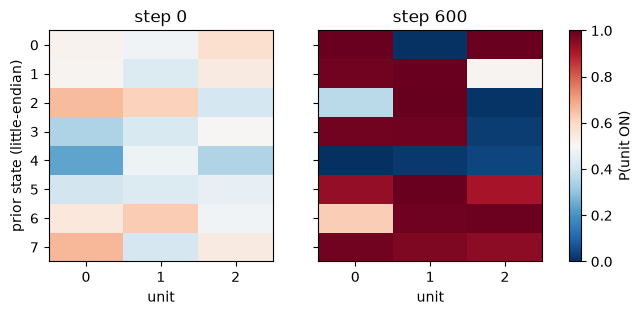

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3), sharey=True)
for ax, (step, on) in zip(axes, snapshots.items(), strict=True):
	image = ax.imshow(on, vmin=0, vmax=1, cmap="RdBu_r", aspect="auto")
	ax.set_title(f"step {step}")
	ax.set_xlabel("unit")
	ax.set_xticks(range(N))
axes[0].set_ylabel("prior state (little-endian)")
fig.colorbar(image, ax=axes, label="P(unit ON)", fraction=0.04)

## Caveats, honestly

- The exact φ_s is piecewise smooth: at partition ties the gradient is a subgradient
  (JAX splits it evenly), and optima sit on tie ridges — hence the annealed surrogate
  for the ascent and small steps near convergence.
- As probabilities saturate, some specified-state probabilities approach 1 and the
  landscape flattens; logit parameterization keeps the iterates in the interior.
- `soft_system_phi` is a **named approximation**. Every number *reported* here
  (φ_s, big Φ, distinction counts) is exact.

From here: larger `n`, ascend big Φ directly, compare measures under the same ascent
(does climbing φ_s also climb 3.0's Φ?), or descend — sculpting minimally integrated
systems is the same gradient with the opposite sign. This program lives in
`experiments/` (start with the gradient audit, `e00_gradient_audit.ipynb`).